# 静息态数据 Epoch 切分和 AutoReject

静息态数据没有event markers，使用固定时长切分

In [1]:
# 导入必要的库
import os
import os.path as op
import mne
import numpy as np
from autoreject import AutoReject
import matplotlib.pyplot as plt

In [ ]:
# 设置路径
# 完整被试列表
# sub_ids = ['001', '021', '022', '024', '047', '049', '051', '071', '072', '073', '076', '092']

# 测试：只处理之前没有montage的被试
sub_ids = ['022', '024', '051', '071', '076']

data_path_ica = r'.\data\4raw_ica\\'
save_path_epoch = r'.\data\5epoch\\'
save_path_epoch_clean = r'.\data\6epoch_clean\\'

# 创建输出目录
os.makedirs(save_path_epoch, exist_ok=True)
os.makedirs(save_path_epoch_clean, exist_ok=True)

# 选择测试被试
sub_id = sub_ids[0]  # 测试被试 022

## Epoch 切分参数说明

**静息态数据切分策略**：

1. **采样率**: 统一为 500 Hz（预处理阶段已重采样）

2. **Epoch 长度选择**：
   - 2秒：适合高频分析（gamma波段），频率分辨率 0.5 Hz
   - 4秒：适合中频分析（alpha, beta），频率分辨率 0.25 Hz
   - **10秒：适合低频分析（delta, theta）- 推荐用于 theta 分析**
     - 频率分辨率：0.1 Hz
     - 对于 theta (4-8 Hz)，可以精确区分 4.0, 4.1, 4.2... Hz
     - 10秒 × 500 Hz = 5000 采样点

3. **为什么 theta 需要更长的 epoch**：
   - Theta 波周期约 125-250ms (4-8 Hz)
   - 10秒 epoch 包含 40-80 个完整周期
   - 提供稳定的频率估计

4. **重叠 (overlap)**：
   - 50% overlap 可以增加epochs数量，提高统计效力
   - 但会引入数据依赖性

5. **为什么不用baseline**：
   - 静息态没有刺激事件，不需要baseline校正
   - 任务态才需要baseline（通常是刺激前的时间段）

In [ ]:
# 读取ICA处理后的数据
fname = op.join(data_path_ica + sub_id + '_raw.fif')
raw = mne.io.read_raw_fif(fname, preload=True, verbose=None)

print(f'被试 {sub_id}:')
print(f'  通道数: {len(raw.ch_names)}')
print(f'  采样率: {raw.info["sfreq"]} Hz')
print(f'  时长: {raw.times[-1]:.2f} 秒')

# 检查采样率是否为 500 Hz
expected_sfreq = 500
if raw.info['sfreq'] != expected_sfreq:
    print(f'\n⚠ 警告: 采样率不是 {expected_sfreq} Hz!')
    print(f'  请确保预处理阶段已进行重采样')
else:
    print(f'\n✓ 采样率正确: {expected_sfreq} Hz')

In [ ]:
# 方案1: 固定时长切分（无重叠）- 适合 theta 分析
epoch_duration = 10.0  # 10秒epochs，适合低频（delta, theta）分析

# 创建伪事件（每10秒一个）
events = mne.make_fixed_length_events(raw, duration=epoch_duration)

# 计算预期采样点数（500 Hz × 10秒 = 5000 + 1 = 5001）
expected_samples = int(epoch_duration * raw.info['sfreq']) + 1

print(f'\n创建的epochs数量: {len(events)}')
print(f'每个epoch时长: {epoch_duration} 秒')
print(f'频率分辨率: {1/epoch_duration} Hz')
print(f'预期采样点数: {expected_samples} (包含端点)')

# 创建epochs（静息态不需要baseline）
epochs = mne.Epochs(raw, events, 
                    tmin=0, tmax=epoch_duration,
                    baseline=None,  # 静息态不用baseline
                    preload=True,
                    proj=False,  # 不使用SSP投影
                    detrend=1,  # 去除线性趋势
                    verbose=None)

print(f'\nEpochs信息:')
print(f'  Epochs数量: {len(epochs)}')
print(f'  时间范围: {epochs.tmin} 到 {epochs.tmax} 秒')
print(f'  采样点数: {len(epochs.times)}')
print(f'  采样率: {epochs.info["sfreq"]} Hz')

In [5]:
# 方案2: 固定时长切分（50%重叠）- 可选
# 如果需要更多epochs，可以使用重叠切分

epoch_duration = 10.0
overlap = 5.0  # 50% 重叠

events_overlap = mne.make_fixed_length_events(raw, 
                                              duration=epoch_duration,
                                              overlap=overlap)

epochs_overlap = mne.Epochs(raw, events_overlap,
                           tmin=0, tmax=epoch_duration,
                           baseline=None,
                           preload=True,
                           proj=False,
                           detrend=1,
                           verbose=None)

print(f'\n重叠切分epochs数量: {len(epochs_overlap)}')
print(f'相比无重叠增加了: {len(epochs_overlap) - len(epochs)} 个epochs')

Not setting metadata
69 matching events found
No baseline correction applied
Using data from preloaded Raw for 69 events and 10001 original time points ...
0 bad epochs dropped

重叠切分epochs数量: 69
相比无重叠增加了: 34 个epochs


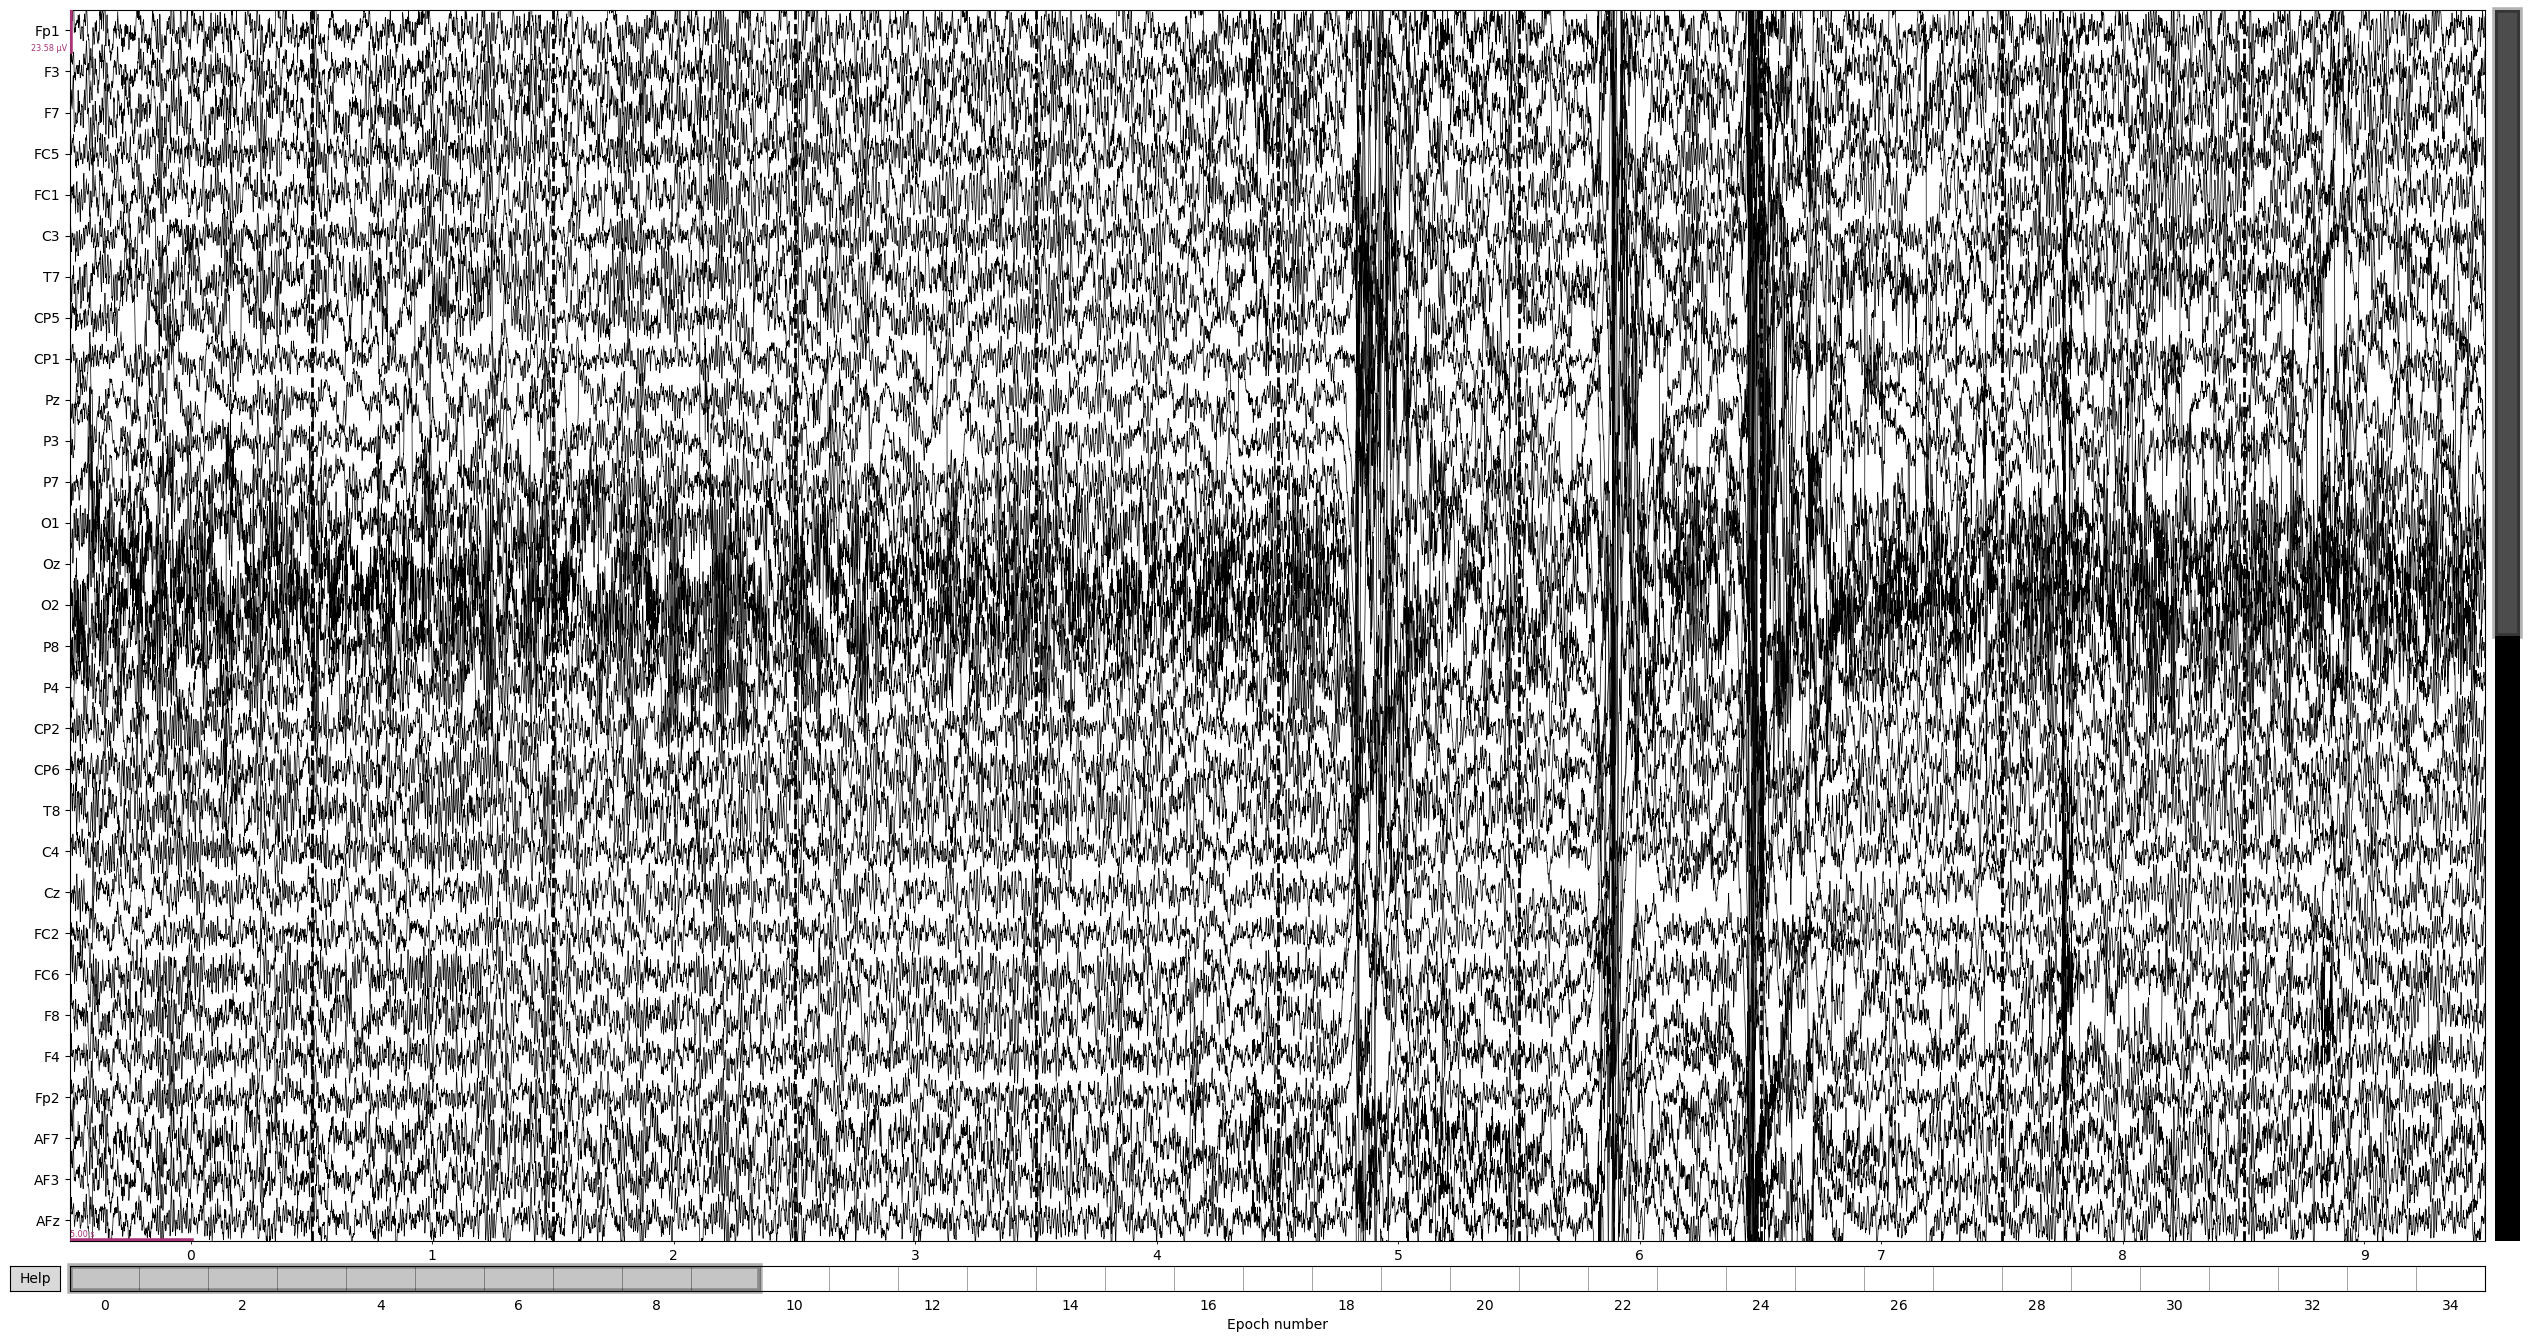

In [7]:
# 可视化检查epochs
%matplotlib qt
epochs.plot(n_epochs=10, n_channels=30, scalings='auto')

In [8]:
# 保存原始epochs
epochs.save(save_path_epoch + sub_id + '-epo.fif', overwrite=True)
print(f'✓ 已保存原始epochs到: {save_path_epoch}{sub_id}-epo.fif')

✓ 已保存原始epochs到: .\data\5epoch\\001-epo.fif


## AutoReject 参数说明

**AutoReject** 自动检测和修复/拒绝坏的epochs：

1. **n_interpolates**: 尝试插值的通道数
   - [1, 4, 32]: 从少到多尝试
   - 静息态可以适当增加：[1, 4, 8, 16]

2. **consensus_percs**: 一致性阈值
   - 0-1之间，决定多少通道坏了就拒绝整个epoch
   - 0.1 = 10%通道坏就拒绝

3. **thresh_method**: 阈值搜索方法
   - 'random_search': 快速但可能不是最优
   - 'bayesian_optimization': 慢但更优（推荐用于最终分析）

In [9]:
# AutoReject 自动去除坏的epochs
print('\n开始 AutoReject 处理...')

# 设置AutoReject参数
n_interpolates = np.array([1, 4, 8, 16])  # 静息态可以多尝试几个
consensus_percs = np.linspace(0, 0.3, 11)  # 0-30%

# 选择EEG通道
picks = mne.pick_types(epochs.info, meg=False, eeg=True, stim=False, 
                       eog=False, include=[], exclude=[])

# 创建AutoReject对象
ar = AutoReject(n_interpolates, consensus_percs, 
                picks=picks,
                thresh_method='random_search',  # 快速搜索
                random_state=42,
                n_jobs=1,  # 并行处理
                verbose=True)

# 训练和应用AutoReject
ar.fit(epochs)
epochs_clean = ar.transform(epochs)

print(f'\nAutoReject 结果:')
print(f'  原始epochs: {len(epochs)}')
print(f'  清理后epochs: {len(epochs_clean)}')
print(f'  拒绝的epochs: {len(epochs) - len(epochs_clean)}')
print(f'  保留率: {len(epochs_clean)/len(epochs)*100:.1f}%')


开始 AutoReject 处理...
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/59 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/59 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/35 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/4 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/35 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.30 and n_interpolate=16


  0%|          | Repairing epochs : 0/35 [00:00<?,       ?it/s]

Dropped 10 epochs: 5, 6, 7, 11, 12, 13, 14, 15, 17, 27

AutoReject 结果:
  原始epochs: 35
  清理后epochs: 25
  拒绝的epochs: 10
  保留率: 71.4%


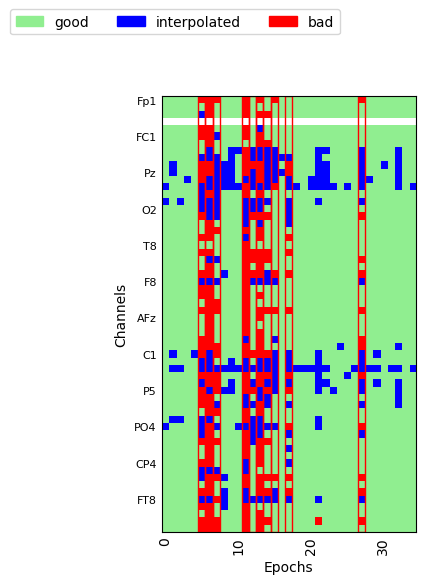

In [10]:
# 可视化AutoReject结果
# 显示哪些epochs被拒绝/插值
ar.get_reject_log(epochs).plot('horizontal')

In [ ]:
# 对比清理前后的效果

# 1. 计算平均 evoked
evoked_original = epochs.average()
evoked_clean = epochs_clean.average()

print('Evoked 信息:')
print(f'  原始 epochs 平均: {len(epochs)} 个 epochs')
print(f'  清理后 epochs 平均: {len(epochs_clean)} 个 epochs')

# 2. 对比波形图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

evoked_original.plot(axes=axes[0], show=False, spatial_colors=True, gfp=True)
axes[0].set_title(f'原始 Epochs 平均 (n={len(epochs)})', fontsize=12)

evoked_clean.plot(axes=axes[1], show=False, spatial_colors=True, gfp=True)
axes[1].set_title(f'AutoReject 清理后 (n={len(epochs_clean)})', fontsize=12)

plt.tight_layout()

# 3. 保存对比图
fig_path_evoked = r'.\figures\evoked_compare\\'
os.makedirs(fig_path_evoked, exist_ok=True)
fig.savefig(f'{fig_path_evoked}{sub_id}_evoked_compare.png', 
           dpi=150, bbox_inches='tight')
print(f'\n✓ 已保存对比图到: {fig_path_evoked}{sub_id}_evoked_compare.png')

plt.show()

In [ ]:
# 保存清理后的epochs和evoked
epochs_clean.save(save_path_epoch_clean + sub_id + '-epo.fif', overwrite=True)
print(f'✓ 已保存清理后epochs到: {save_path_epoch_clean}{sub_id}-epo.fif')

# 保存 evoked 用于后续分析
save_path_evoked = r'.\data\7evoked\\'
os.makedirs(save_path_evoked, exist_ok=True)

evoked_clean.save(save_path_evoked + sub_id + '-ave.fif', overwrite=True)
print(f'✓ 已保存 evoked 到: {save_path_evoked}{sub_id}-ave.fif')

---
## 批量处理所有被试

In [16]:
# 测试：只处理之前没有montage的被试
# sub_ids = ['022', '024', ]
# 全部
sub_ids = ['001', '021', '022', '024', '047', '049', '051', '071', '072', '073', '076', '092']

# 批量处理所有被试
import matplotlib
matplotlib.use('Agg')  # 非交互式后端

# 创建所有输出目录
fig_path_evoked = r'.\figures\evoked_compare\\'
save_path_evoked = r'.\data\7evoked\\'
os.makedirs(fig_path_evoked, exist_ok=True)
os.makedirs(save_path_evoked, exist_ok=True)

success_count = 0
failed_list = []
epoch_stats = []

print(f'开始批量处理 {len(sub_ids)} 个被试...\n')

for sub_id in sub_ids:
    try:
        print(f'[{sub_id}] 开始处理...')

        # 1. 读取数据并统一设置montage
        fname = op.join(data_path_ica + sub_id + '_raw.fif')
        raw = mne.io.read_raw_fif(fname, preload=True, verbose=None)
        print(f'[{sub_id}]   数据时长: {raw.times[-1]:.2f} 秒')

        # 统一设置标准10-20电极位置（保持所有被试一致）
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, match_case=False, on_missing='warn')
        print(f'[{sub_id}]   ✓ 已设置标准10-20 montage')

        # 2. 创建epochs
        epoch_duration = 10.0
        events = mne.make_fixed_length_events(raw, duration=epoch_duration)
        epochs = mne.Epochs(raw, events,
                            tmin=0, tmax=epoch_duration,
                            baseline=None,
                            preload=True,
                            proj=False,
                            detrend=1,
                            verbose=None)

        print(f'[{sub_id}]   创建了 {len(epochs)} 个epochs')

        # 3. 保存原始epochs
        epochs.save(save_path_epoch + sub_id + '-epo.fif', overwrite=True)

        # 4. AutoReject处理
        n_interpolates = np.array([1, 4, 8, 16])
        consensus_percs = np.linspace(0, 0.3, 11)
        picks = mne.pick_types(epochs.info, meg=False, eeg=True, stim=False,
                               eog=False, include=[], exclude=[])

        ar = AutoReject(n_interpolates, consensus_percs,
                        picks=picks,
                        thresh_method='random_search',
                        random_state=42,
                        n_jobs=1,
                        verbose=False)

        ar.fit(epochs)
        epochs_clean = ar.transform(epochs)

        rejected_count = len(epochs) - len(epochs_clean)
        retention_rate = len(epochs_clean) / len(epochs) * 100

        print(f'[{sub_id}]   AutoReject: {len(epochs)} → {len(epochs_clean)} epochs (保留率: {retention_rate:.1f}%)')

        # 5. 保存清理后的epochs
        epochs_clean.save(save_path_epoch_clean + sub_id + '-epo.fif', overwrite=True)

        # 6. 计算evoked并保存对比图
        evoked_original = epochs.average()
        evoked_clean = epochs_clean.average()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        evoked_original.plot(axes=axes[0], show=False, spatial_colors=True, gfp=True)
        axes[0].set_title(f'原始 Epochs 平均 (n={len(epochs)})', fontsize=12)
        evoked_clean.plot(axes=axes[1], show=False, spatial_colors=True, gfp=True)
        axes[1].set_title(f'AutoReject 清理后 (n={len(epochs_clean)})', fontsize=12)
        plt.tight_layout()

        fig.savefig(f'{fig_path_evoked}{sub_id}_evoked_compare.png',
                   dpi=150, bbox_inches='tight')
        plt.close(fig)

        # 7. 保存evoked
        evoked_clean.save(save_path_evoked + sub_id + '-ave.fif', overwrite=True)

        # 8. 记录统计信息
        epoch_stats.append({
            'subject': sub_id,
            'original_epochs': len(epochs),
            'clean_epochs': len(epochs_clean),
            'rejected_epochs': rejected_count,
            'retention_rate': retention_rate
        })

        print(f'[{sub_id}] ✓ 处理完成\n')
        success_count += 1

    except Exception as e:
        print(f'[{sub_id}] ✗ 处理失败: {str(e)}\n')
        failed_list.append(sub_id)
        continue

# 显示结果汇总
print('='*60)
print(f'批量处理完成！')
print(f'成功: {success_count}/{len(sub_ids)}')
if failed_list:
    print(f'\n失败列表: {failed_list}')
else:
    print('所有被试处理成功！')

# 显示统计信息
if epoch_stats:
    print('\n=== Epoch统计 ===')
    print(f'{"被试":<8} {"原始":<8} {"清理后":<8} {"拒绝":<8} {"保留率":<8}')
    print('-'*50)
    for stat in epoch_stats:
        print(f'{stat["subject"]:<8} {stat["original_epochs"]:<8} {stat["clean_epochs"]:<8} '
              f'{stat["rejected_epochs"]:<8} {stat["retention_rate"]:<8.1f}%')

    # 计算平均值
    avg_retention = np.mean([s['retention_rate'] for s in epoch_stats])
    print('-'*50)
    print(f'平均保留率: {avg_retention:.1f}%')

print(f'\n输出文件:')
print(f'  原始epochs: {save_path_epoch}')
print(f'  清理后epochs: {save_path_epoch_clean}')
print(f'  Evoked数据: {save_path_evoked}')
print(f'  对比图: {fig_path_evoked}')
print('='*60)

开始批量处理 12 个被试...

[001] 开始处理...
Opening raw data file .\data\4raw_ica\\001_raw.fif...
    Range : 0 ... 350219 =      0.000 ...   350.219 secs
Ready.
Reading 0 ... 350219  =      0.000 ...   350.219 secs...
[001]   数据时长: 350.22 秒
[001]   ✓ 已设置标准10-20 montage
Not setting metadata
35 matching events found
No baseline correction applied
Using data from preloaded Raw for 35 events and 10001 original time points ...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_681304\2847288625.py:33: RuntimeWarning: Not setting position of 1 eog channel found in montage:
['F9']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, match_case=False, on_missing='warn')


0 bad epochs dropped
[001]   创建了 35 个epochs
Overwriting existing file.
Overwriting existing file.
Dropped 10 epochs: 5, 6, 7, 11, 12, 13, 14, 15, 17, 27
[001]   AutoReject: 35 → 25 epochs (保留率: 71.4%)
Overwriting existing file.
Overwriting existing file.


D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:565: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current 

[001] ✓ 处理完成

[021] 开始处理...
Opening raw data file .\data\4raw_ica\\021_raw.fif...
    Range : 0 ... 355499 =      0.000 ...   355.499 secs
Ready.
Reading 0 ... 355499  =      0.000 ...   355.499 secs...
[021]   数据时长: 355.50 秒
[021]   ✓ 已设置标准10-20 montage
Not setting metadata
35 matching events found
No baseline correction applied
Using data from preloaded Raw for 35 events and 10001 original time points ...


...

[076] ✓ 处理完成

[092] 开始处理...
Opening raw data file .\data\4raw_ica\\092_raw.fif...
    Range : 0 ... 314879 =      0.000 ...   314.879 secs
Ready.
Reading 0 ... 314879  =      0.000 ...   314.879 secs...
[092]   数据时长: 314.88 秒
[092]   ✓ 已设置标准10-20 montage
Not setting metadata
31 matching events found
No baseline correction applied
Using data from preloaded Raw for 31 events and 10001 original time points ...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_681304\2847288625.py:33: RuntimeWarning: Not setting position of 1 eog channel found in montage:
['F9']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, match_case=False, on_missing='warn')


0 bad epochs dropped
[092]   创建了 31 个epochs
Overwriting existing file.
Overwriting existing file.
Dropped 15 epochs: 0, 2, 5, 7, 9, 10, 12, 16, 18, 21, 22, 27, 28, 29, 30
[092]   AutoReject: 31 → 16 epochs (保留率: 51.6%)
Overwriting existing file.
Overwriting existing file.


D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:235: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  axis.get_figure().canvas.draw()
D:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\mne\viz\evoked.py:565: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current 

[092] ✓ 处理完成

批量处理完成！
成功: 12/12
所有被试处理成功！

=== Epoch统计 ===
被试       原始       清理后      拒绝       保留率     
--------------------------------------------------
001      35       25       10       71.4    %
021      35       32       3        91.4    %
022      38       22       16       57.9    %
024      30       25       5        83.3    %
047      31       18       13       58.1    %
049      33       23       10       69.7    %
051      34       29       5        85.3    %
071      37       33       4        89.2    %
072      48       25       23       52.1    %
073      37       28       9        75.7    %
076      34       18       16       52.9    %
092      31       16       15       51.6    %
--------------------------------------------------
平均保留率: 69.9%

输出文件:
  原始epochs: .\data\5epoch\\
  清理后epochs: .\data\6epoch_clean\\
  Evoked数据: .\data\7evoked\\
  对比图: .\figures\evoked_compare\\
